# Label Alignment Test

In [1]:
from src.data import DATA_DIR_INTERIM, DATA_DIR_PROCESSED
from src.io import load_qrel_from_path, read_metadata
from src.config import MODEL_SORTER, PROMPT_SORTER
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.measures_agreement import CohenKappa, MeanAverageError
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

/Users/jueri/projects/conf26-generating-topics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASETS = {
    "robust": {
        "binary": "label-alignment-robust-qrels-topics-generated-binary.tsv",
        "graded": "label-alignment-robust-qrels-topics-generated.tsv",
        "irds": "disks45/nocr/trec-robust-2004",
        "results_dir": "qrels-topics-generated",
    },
    "dl19": {
        "binary": "label-alignment-dl19-qrels-topics-generated-full-binary.tsv",
        "graded": "label-alignment-dl19-qrels-topics-generated-full.tsv",
        "irds": "msmarco-passage/trec-dl-2019/judged",
        "results_dir": "qrels-topics-generated-full",
    },
    "dl20": {
        "binary": "label-alignment-dl20-qrels-topics-generated-full-binary.tsv",
        "graded": "label-alignment-dl20-qrels-topics-generated-full.tsv",
        "irds": "msmarco-passage/trec-dl-2020/judged",
        "results_dir": "qrels-topics-generated-full",
    },
}

In [ ]:
def prepare_data(dataset):
    # load metadata
    metadata = read_metadata(
        DATA_DIR_INTERIM / dataset / DATASETS[dataset]["results_dir"]
    )
    metadata = metadata.fillna(0)
    metadata.replace(
        {
            "GPT-OSS-120B-O": "gpt-oss-120b",
            "GPT-OSS-120B": "gpt-oss-120b",
            "GPT-OSS-20B": "gpt-oss-20b",
            "Qwen3-Next-80B": "Qwen3-Next",
        },
        inplace=True,
    )

    metadata["topics_model"].fillna("TREC", inplace=True)

    # only the same model for the topic and qrels and only one query
    metadata = metadata[
        (metadata["topics_nqueries"] == 1.0)
        & (metadata["model"] == metadata["topics_model"])
    ]
    metadata["model"] = pd.Categorical(
        metadata["model"], ["gpt-oss-120b", "gpt-oss-20b", "Qwen3-Next", "Qwen3-30B"]
    )
    metadata["topics_prompt"] = pd.Categorical(metadata["topics_prompt"], PROMPT_SORTER)

    metadata["display_name"] = metadata.apply(
        lambda row: f"{row['topics_prompt']}-{int(float(row['topics_nqueries']))}-{int(float(row['topics_ndocspos']))}-{int(float(row['topics_ndocsneg']))}",
        axis=1,
    )

    # load results
    df = pd.read_csv(DATA_DIR_PROCESSED / DATASETS[dataset]["graded"], sep="\t")
    df = df.replace("Cohens $\kappa$", "kappa")
    df = df.drop_duplicates()
    df = df.pivot(index="name", columns="measure", values="value").reset_index()

    df = metadata.merge(df[["name", "kappa", "MAE"]], left_on="name", right_on="name")
    df["kappa"] = df["kappa"].apply(pd.to_numeric, errors="coerce")

    return df

<>:27: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_7074/2148387909.py:27: SyntaxWarning: invalid escape sequence '\k'
  df = df.replace("Cohens $\kappa$", "kappa")


Load qrels sets

<>:27: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_7074/504240067.py:27: SyntaxWarning: invalid escape sequence '\k'
  axes[idx].set_ylabel("Cohen's $\kappa$")
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_7074/2148387909.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_7074/2148387909.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

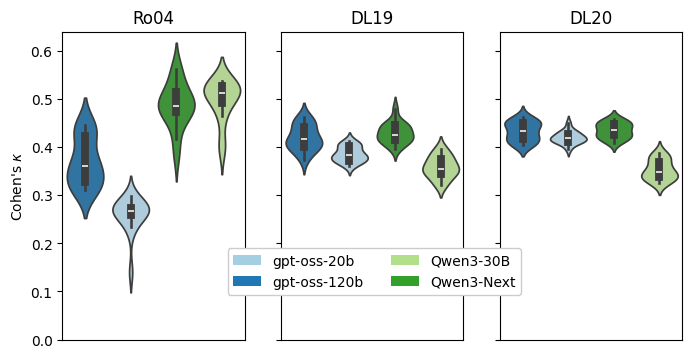

In [6]:
from matplotlib.patches import Patch
from pathlib import Path

fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharey=True)

# Get unique models across all datasets for consistent coloring
all_models = []
for dataset in ["robust", "dl19", "dl20"]:
    df = prepare_data(dataset)
    all_models.extend(df["model"].unique())
unique_models = pd.Series(all_models).unique()

# Create color palette
palette = sns.color_palette("Paired", n_colors=len(unique_models))
color_map = dict(zip(unique_models, palette))

for idx, dataset in enumerate(["robust", "dl19", "dl20"]):
    df = prepare_data(dataset)
    dataset_map = {"robust": "Ro04", "dl19": "DL19", "dl20": "DL20"}

    # Get colors for this dataset's models
    colors = [color_map[model] for model in df["model"].cat.categories]

    sns.violinplot(data=df, x="model", y="kappa", ax=axes[idx], palette=colors)
    axes[idx].set_title(dataset_map[dataset])
    if idx == 0:
        axes[idx].set_ylabel("Cohen's $\kappa$")
    else:
        axes[idx].set_ylabel("")
    axes[idx].set_xlabel("")
    axes[idx].set_xticklabels([])  # Remove x-tick labels
    axes[idx].tick_params(axis="x", length=0)  # Remove x-tick marks
    axes[idx].set_ylim(0, 0.64)

# Create legend with color-coded models

legend_elements = [
    Patch(facecolor=color_map[model], label=model) for model in unique_models
]
legend = fig.legend(
    handles=legend_elements,
    loc="center",
    bbox_to_anchor=(0.515, 0.28),
    ncol=2,
)
frame = legend.get_frame()
frame.set_facecolor("white")
frame.set_alpha(1)

# plt.tight_layout()
# plt.show()

plt.savefig(
    "../publication/paper/figures/label-agreement-llms.pdf",
    dpi=300,
    bbox_inches="tight",
)

<>:26: SyntaxWarning: invalid escape sequence '\k'
<>:26: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1708085677.py:26: SyntaxWarning: invalid escape sequence '\k'
  p.set_ylabel("Cohen's $\kappa$")
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/2148387909.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/2148387909.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

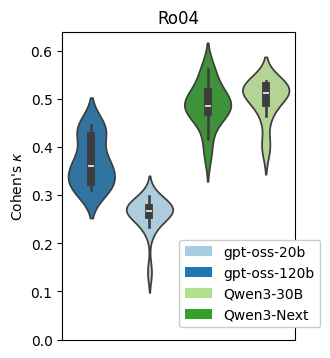

In [ ]:
from matplotlib.patches import Patch
from pathlib import Path

fig = plt.figure(figsize=(3, 4))

# Get unique models across all datasets for consistent coloring
all_models = []
dataset = "robust"
# for dataset in ["robust", "dl19", "dl20"]:
df = prepare_data(dataset)
all_models.extend(df["model"].unique())
unique_models = pd.Series(all_models).unique()

# Create color palette
palette = sns.color_palette("Paired", n_colors=len(unique_models))
color_map = dict(zip(unique_models, palette))

df = prepare_data(dataset)
dataset_map={"robust": "Ro04", "dl19": "DL19", "dl20": "DL20"}

# Get colors for this dataset's models
colors = [color_map[model] for model in df["model"].cat.categories]

p = sns.violinplot(data=df, x="model", y="kappa", palette=colors)
p.set_title(dataset_map[dataset])
p.set_ylabel("Cohen's $\kappa$")
p.set_xlabel("")
p.set_xticklabels([])  # Remove x-tick labels
p.tick_params(axis="x", length=0)  # Remove x-tick marks
p.set_ylim(0, 0.64)

# Create legend with color-coded models
legend_elements = [
    Patch(facecolor=color_map[model], label=model) for model in unique_models
]
legend = fig.legend(
    handles=legend_elements,
    loc="center",
    bbox_to_anchor=(0.75, 0.28),
    ncol=1,
)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_alpha(1)

# plt.tight_layout()
# plt.show()

plt.savefig(
    "label-agreement-models.pdf",
    dpi=300,
    bbox_inches="tight",
)

# Prompts

In [ ]:
dataset = "robust"

# load metadata
metadata = read_metadata(DATA_DIR_INTERIM / dataset / DATASETS[dataset]["results_dir"])
metadata = metadata.fillna(0)
metadata.replace(
    {
        "GPT-OSS-120B-O": "gpt-oss-120b",
        "GPT-OSS-120B": "gpt-oss-120b",
        "GPT-OSS-20B": "gpt-oss-20b",
        "Qwen3-Next-80B": "Qwen3-Next",
    },
    inplace=True,
)

metadata["topics_model"].fillna("TREC", inplace=True)

# only the same model for the topic and qrels and only one query
metadata = metadata[
    (metadata["topics_nqueries"] <= 1.0)
    & (metadata["model"] == metadata["topics_model"])
]
metadata["model"] = pd.Categorical(
    metadata["model"], ["gpt-oss-120b", "gpt-oss-20b", "Qwen3-Next", "Qwen3-30B"]
)
metadata["topics_prompt"] = pd.Categorical(metadata["topics_prompt"], PROMPT_SORTER)
metadata["topics_prompt"] = metadata["topics_prompt"].cat.remove_unused_categories()

metadata["display_name"] = metadata.apply(
    lambda row: f"{row['topics_prompt']}-{int(float(row['topics_nqueries']))}-{int(float(row['topics_ndocspos']))}-{int(float(row['topics_ndocsneg']))}",
    axis=1,
)

# load results
df = pd.read_csv(DATA_DIR_PROCESSED / DATASETS[dataset]["graded"], sep="\t")
df = df.replace("Cohens $\kappa$", "kappa")
df = df.drop_duplicates()
df = df.pivot(index="name", columns="measure", values="value").reset_index()

df = metadata.merge(df[["name", "kappa", "MAE"]], left_on="name", right_on="name")
df["kappa"] = df["kappa"].apply(pd.to_numeric, errors="coerce")
df["display_name"] = df["topics_prompt"].str.replace("topic-", "")
ordered_display_names = df.sort_values("topics_prompt")["display_name"].unique()
df["display_name"] = pd.Categorical(
    df["display_name"], categories=ordered_display_names, ordered=True
)

<>:29: SyntaxWarning: invalid escape sequence '\k'
<>:29: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/81510960.py:29: SyntaxWarning: invalid escape sequence '\k'
  df = df.replace("Cohens $\kappa$", "kappa")
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/81510960.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/81510960.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

<>:16: SyntaxWarning: invalid escape sequence '\k'
<>:16: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1691707170.py:16: SyntaxWarning: invalid escape sequence '\k'
  p.set_ylabel("Cohen's $\kappa$")


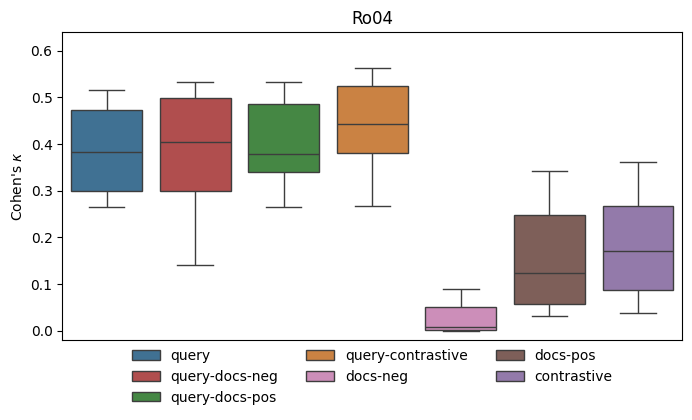

In [ ]:
my_colors = [
    "#3274A1",
    "#C03E3E",
    "#3A9239",
    "#E1812C",
    "#D684BD",
    "#845B53",
    "#9372B2",
]
custom_palette = dict(zip(ordered_display_names, my_colors))

fig = plt.figure(figsize=(8, 4))

# 2. Explicitly set 'hue' and 'palette'
p = sns.boxplot(
    data=df,
    x="display_name",
    y="kappa",
    hue="display_name",
    palette=custom_palette,
    legend=True,
)

p.set_ylabel("Cohen's $\kappa$")
p.set_xlabel("")
p.set_title("Ro04")
p.set_ylim(-0.02, 0.64)

# 3. Handle the legend and axis
p.set_xticklabels([])
p.tick_params(axis="x", length=0)

# Move the legend safely without overwriting labels
plt.legend(
    bbox_to_anchor=(0.5, -0.25), ncol=3, loc="lower center", title="", frameon=False
)

# plt.tight_layout()
# plt.show()

plt.savefig(
    "label-agreement-prompts.pdf",
    dpi=300,
    bbox_inches="tight",
)

# contexts

In [ ]:
dataset = "robust"

# load metadata
metadata = read_metadata(DATA_DIR_INTERIM / dataset / DATASETS[dataset]["results_dir"])
metadata = metadata.fillna(0)
metadata.replace(
    {
        "GPT-OSS-120B-O": "gpt-oss-120b",
        "GPT-OSS-120B": "gpt-oss-120b",
        "GPT-OSS-20B": "gpt-oss-20b",
        "Qwen3-Next-80B": "Qwen3-Next",
    },
    inplace=True,
)

metadata["topics_model"].fillna("TREC", inplace=True)

# only the same model for the topic and qrels and only one query
metadata = metadata[
    (metadata["topics_nqueries"] <= 1.0)
    & (metadata["model"] == metadata["topics_model"])
]

metadata["model"] = pd.Categorical(
    metadata["model"], ["gpt-oss-120b", "gpt-oss-20b", "Qwen3-Next", "Qwen3-30B"]
)
metadata["topics_prompt"] = pd.Categorical(metadata["topics_prompt"], PROMPT_SORTER)
metadata["topics_prompt"] = metadata["topics_prompt"].cat.remove_unused_categories()

metadata["display_name"] = metadata.apply(
    lambda row: f"{row['topics_prompt']}-{int(float(row['topics_nqueries']))}-{int(float(row['topics_ndocspos']))}-{int(float(row['topics_ndocsneg']))}",
    axis=1,
)

# load results
df = pd.read_csv(DATA_DIR_PROCESSED / DATASETS[dataset]["graded"], sep="\t")
df = df.replace("Cohens $\kappa$", "kappa")
df = df.drop_duplicates()
df = df.pivot(index="name", columns="measure", values="value").reset_index()

df = metadata.merge(df[["name", "kappa", "MAE"]], left_on="name", right_on="name")
df["kappa"] = df["kappa"].apply(pd.to_numeric, errors="coerce")
df["display_name"] = df["topics_prompt"].str.replace("topic-", "")

ordered_display_names = df.sort_values("topics_prompt")["display_name"].unique()

df["display_name"] = pd.Categorical(
    df["display_name"], categories=ordered_display_names, ordered=True
)

df["context"] = df[["topics_nqueries", "topics_ndocspos", "topics_ndocsneg"]].max(
    axis=1
)

<>:29: SyntaxWarning: invalid escape sequence '\k'
<>:29: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1860771856.py:29: SyntaxWarning: invalid escape sequence '\k'
  df = df.replace("Cohens $\kappa$", "kappa")
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1860771856.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(0)
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1860771856.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

<>:15: SyntaxWarning: invalid escape sequence '\k'
<>:15: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1403141045.py:15: SyntaxWarning: invalid escape sequence '\k'
  p.set_ylabel("Cohen's $\kappa$")
/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_95490/1403141045.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(["1", "2", "3", "4", "5"])


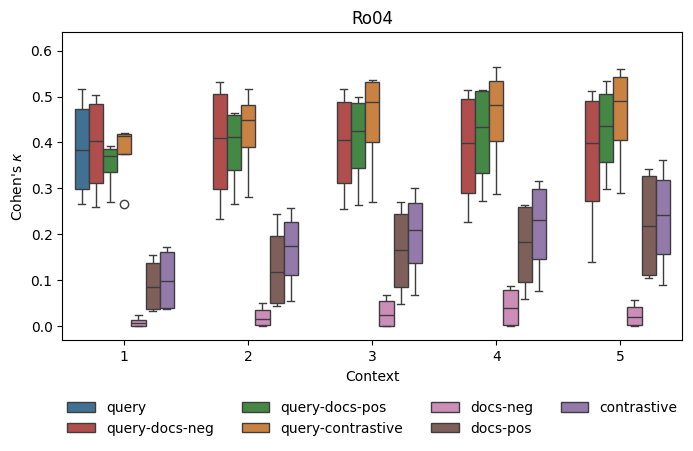

In [ ]:
my_colors = [
    "#3274A1",
    "#C03E3E",
    "#3A9239",
    "#E1812C",
    "#D684BD",
    "#845B53",
    "#9372B2",
]
custom_palette = dict(zip(ordered_display_names, my_colors))

fig = plt.figure(figsize=(8, 4))

p = sns.boxplot(
    data=df,
    x="context",
    y="kappa",
    hue="display_name",
    legend=True,
    palette=custom_palette,
)

p.set_ylabel("Cohen's $\kappa$")
p.set_xlabel("Context")
p.set_title("Ro04")
p.set_ylim(-0.03, 0.64)

# 3. Handle the legend and axis
p.set_xticklabels(["1", "2", "3", "4", "5"])
# p.tick_params(axis="x", length=0)

# # Move the legend safely without overwriting labels
plt.legend(
    bbox_to_anchor=(0.5, -0.35), ncol=4, loc="lower center", title="", frameon=False
)

# # plt.tight_layout()
# # plt.show()

plt.savefig(
    "label-agreement-prompts.pdf",
    dpi=300,
    bbox_inches="tight",
)